In [2]:
# displays static in notebook
%matplotlib inline  
# displays interactive outside notebook
#%matplotlib   
# displays interactive in notebook
#%matplotlib notebook  

# to work correctly with numbers
import numpy as np

# plotting
import matplotlib.pyplot as plt
import matplotlib as mpl

# conversion between coordinate systems
import astropy.coordinates as coord
import astropy.units as u

#from astropy import units as u
from astropy.coordinates import SkyCoord

from scipy import stats

# for making data catalogues that are easily uploaded to Javascript
import json

# for loading fits files
from astropy.io import fits


folder = ''

mpl.rcParams['font.family']='serif'
mpl.rcParams['font.size']=14

In [3]:
# Units

M_earth = 5.97E24
r_earth = 6.37E6
T_earth = 254.0
M_sun = 1.989E30
L_sun = 3.839E26
r_sun = 6.957e8
AU = 1.496E11
pc = 3.086E16
sigma = 5.67E-8
G = 6.67E-11
c = 2.997E8


In [4]:
# adapted from UCSC SIP training activities
# modified to use , delimiting and avoid adding blank line at end of file

def WriteCatalog(catalogName, params, paramNameString):
    #first, create and open the text file for writing. Choose a name: 
    catalog = open(catalogName, 'w')

    #write first row
    catalog.write('# ' + paramNameString + '\n')

    #then, loop through stars and write 1 row for each star.
    for i in range(len(params[0])): #loop over stars
        for j in range(len(params)): #loop over parameters (ra, dec, v, verr,...)
            catalog.write(str(params[j][i]))
            if j < len(params)-1:
                catalog.write(', ')
        if i < len(params[0])-1:
            catalog.write('\n')
    catalog.close()

    return


def Aitoff_on_sky_setup():
    # ra_like and dec_like need to be in radians
    plt.subplot(111, projection="aitoff")
    plt.xticks(np.arange(-np.pi, np.pi+0.001,30 * np.pi/180), [r'180$^{\circ}$',r'150$^{\circ}$', r'120$^{\circ}$', r'90$^{\circ}$',\
                                r'60$^{\circ}$', r'30$^{\circ}$', r'0$^{\circ}$', r'-30$^{\circ}$',\
                                r'-60$^{\circ}$', r'-90$^{\circ}$', r'-120$^{\circ}$', r'-150$^{\circ}$', r'-180$^{\circ}$'])
    print('remember your ra_like and dec_like need to be in radians')
    print('remember to multiply your ra_like by -1')
    return


In [7]:
dataFile = 'Dalya2018.tsv'
dataFile = 'test.tsv'
PGC, RAJ2000, DEJ2000, Dist, z, Bmag, Babs = np.loadtxt(dataFile, unpack = True, delimiter='|')

print(len(Dist))
print(Dist, z)


ra_a = coord.Angle(RAJ2000 * u.degree)
dec_a = coord.Angle(DEJ2000 * u.degree)
ra_wrap = ra_a.wrap_at(180 * u.degree)
ra = ra_wrap.radian
dec = dec_a.radian

sc = SkyCoord(ra=RAJ2000, dec=DEJ2000, unit='deg', frame='fk5', equinox='J2000.0')
l = sc.transform_to('galactic').l
b = sc.transform_to('galactic').b
l_wrap = l.wrap_at(180 * u.degree)
l = l_wrap.radian
b = b.radian
print(l, b)

49104
[ 77.85933544  63.50689583 102.51650554 ...  89.04978446  78.27775834
  77.73602235] [0.014684   0.018728   0.023886   ... 0.01981477 0.022717   0.021133  ]
[ 2.47277012 -1.74860323 -0.42133008 ... -0.58445172  0.73535562
  2.51289227] [-0.19067385  0.34012865  1.13833881 ... -0.13241998 -0.80688702
 -0.85857486]


<Figure size 640x480 with 0 Axes>

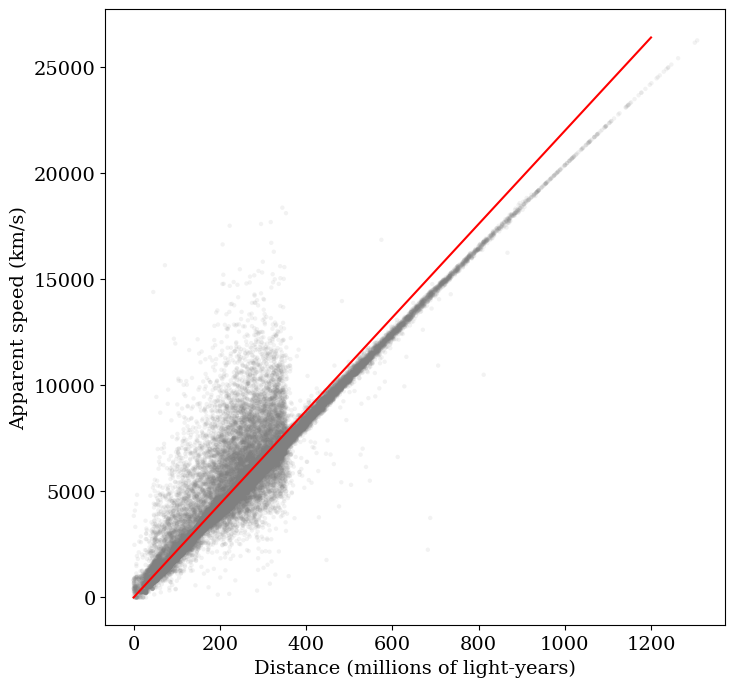

In [9]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(8,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (km/s)')
#plt.xlim(180,-180)
#plt.ylim(-90,90)

plt.scatter(Dist * 3.26156, z*c / 1E3, c = 'gray', s = 10, edgecolors = 'none', alpha=0.1)
plt.plot([0,1200], [0,22*1200], c='red')
plt.savefig('Hubble_plot_GLADE2.jpg')

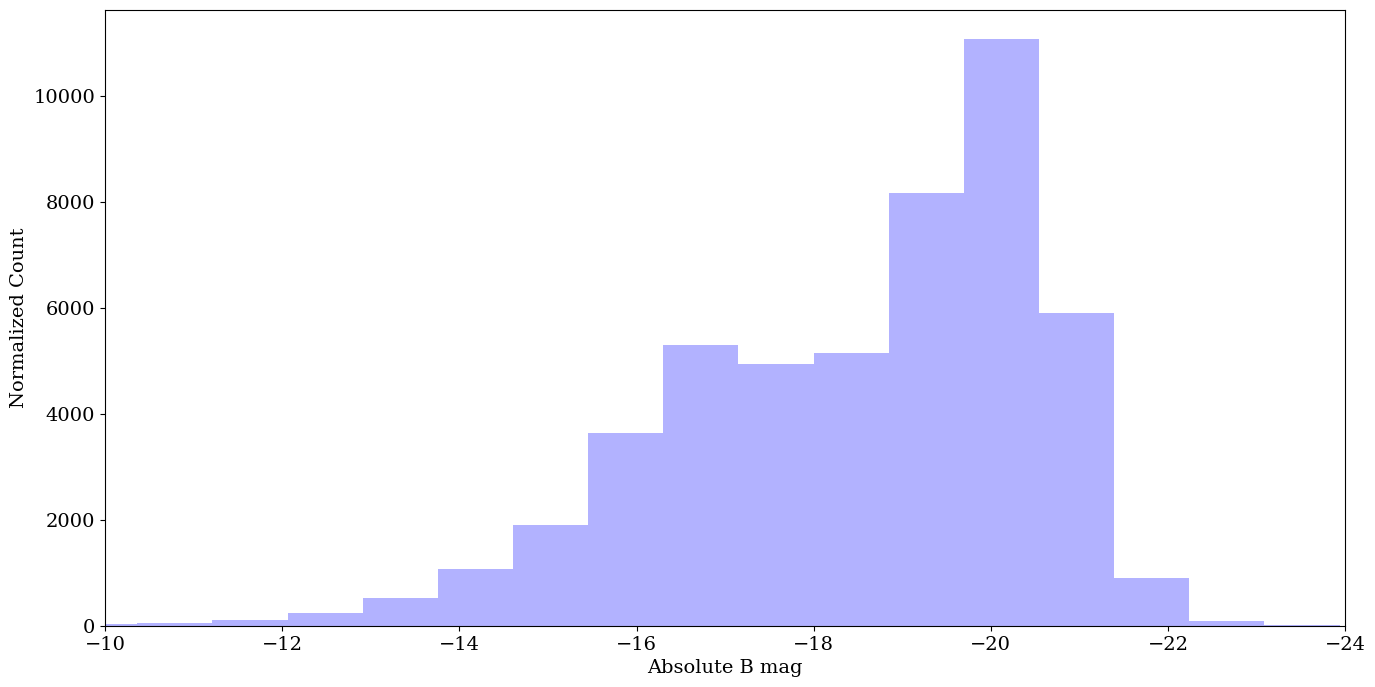

In [11]:
plt.figure(figsize=(16,8))

ax = plt.axes()
_,_,_ = ax.hist(Babs, bins=30, histtype='stepfilled', alpha=0.3, color='b', zorder=1)
#ax.text(150, 0.03, 'MS', color='b')
ax.set_xlim(-10, -24)
ax.set_xlabel(r'Absolute B mag')
ax.set_ylabel('Normalized Count')
plt.savefig('GLADE2_absolute_B_mag.jpg')

[0.0000e+00 0.0000e+00 5.0000e+00 1.6000e+01 6.5000e+01 2.6400e+02
 1.0410e+03 3.7280e+03 9.2800e+03 1.6249e+04 2.2226e+04 2.6494e+04
 2.9723e+04 3.2583e+04 3.5625e+04 3.8986e+04 4.1993e+04 4.4228e+04
 4.5877e+04 4.6929e+04 4.7681e+04 4.8214e+04 4.8545e+04 4.8743e+04
 4.8861e+04 4.8929e+04 4.8981e+04 4.9018e+04 4.9041e+04]
[-24.  -23.5 -23.  -22.5 -22.  -21.5 -21.  -20.5 -20.  -19.5 -19.  -18.5
 -18.  -17.5 -17.  -16.5 -16.  -15.5 -15.  -14.5 -14.  -13.5 -13.  -12.5
 -12.  -11.5 -11.  -10.5 -10. ]


<Figure size 640x480 with 0 Axes>

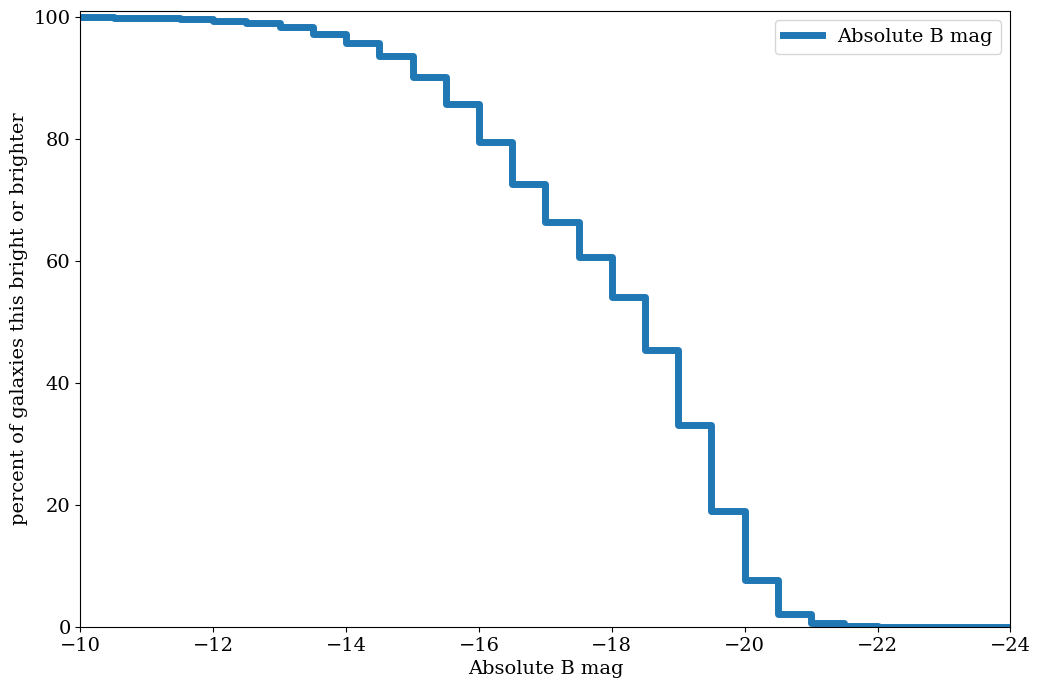

In [13]:
BMAG_cumfreq = stats.cumfreq(Babs, numbins=29, defaultreallimits=(-25, -10))
print(BMAG_cumfreq.cumcount)
x = np.arange(-24, -9.9, 0.5)
print(x)

plt.clf()
f= plt.figure(figsize=(12,8))
plt.xlim(-10, -24)
plt.ylim(0,101)
plt.xlabel(r'Absolute B mag')
plt.ylabel('percent of galaxies this bright or brighter')    
plt.step(x,BMAG_cumfreq.cumcount / BMAG_cumfreq.cumcount[-1] * 100, where='post', label='Absolute B mag', linewidth = '5')
plt.legend()
plt.savefig('GLADE2_absolute_B_mag_cumulative.jpg')

<Figure size 640x480 with 0 Axes>

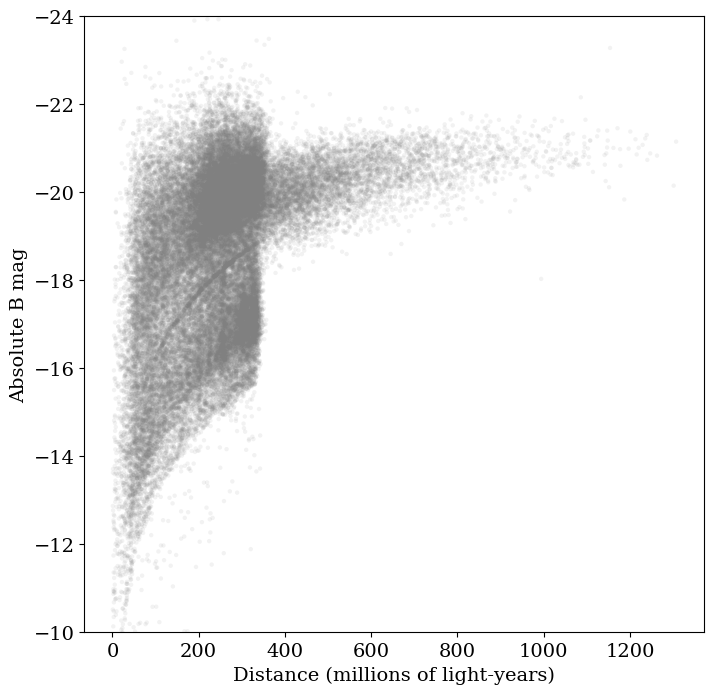

In [15]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(8,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Absolute B mag')
#plt.xlim(180,-180)
plt.ylim(-10, -24)

plt.scatter(Dist * 3.26156, Babs, c = 'gray', s = 10, edgecolors = 'none', alpha=0.1)
#plt.plot([0,1200], [0,22*1200], c='red')
plt.savefig('GLADE2_distance_BMAG.jpg')

remember your ra_like and dec_like need to be in radians
remember to multiply your ra_like by -1


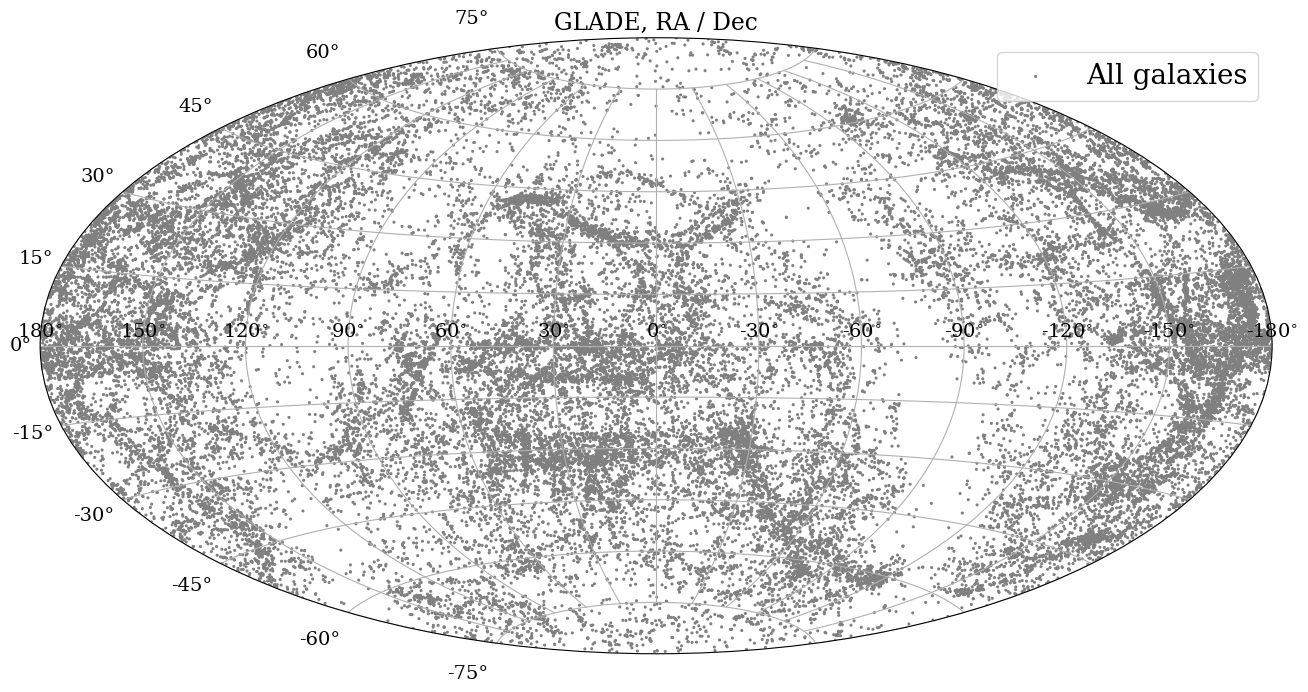

In [17]:
plt.figure(figsize=(16,8))
Aitoff_on_sky_setup()

plt.title("GLADE, RA / Dec")
plt.grid(True)
plt.scatter(-1*ra, dec, c = 'gray', s = 5, edgecolors = 'none', label='All galaxies', alpha=1)
legend = plt.legend(loc='upper right', shadow=False, fontsize=20)

remember your ra_like and dec_like need to be in radians
remember to multiply your ra_like by -1


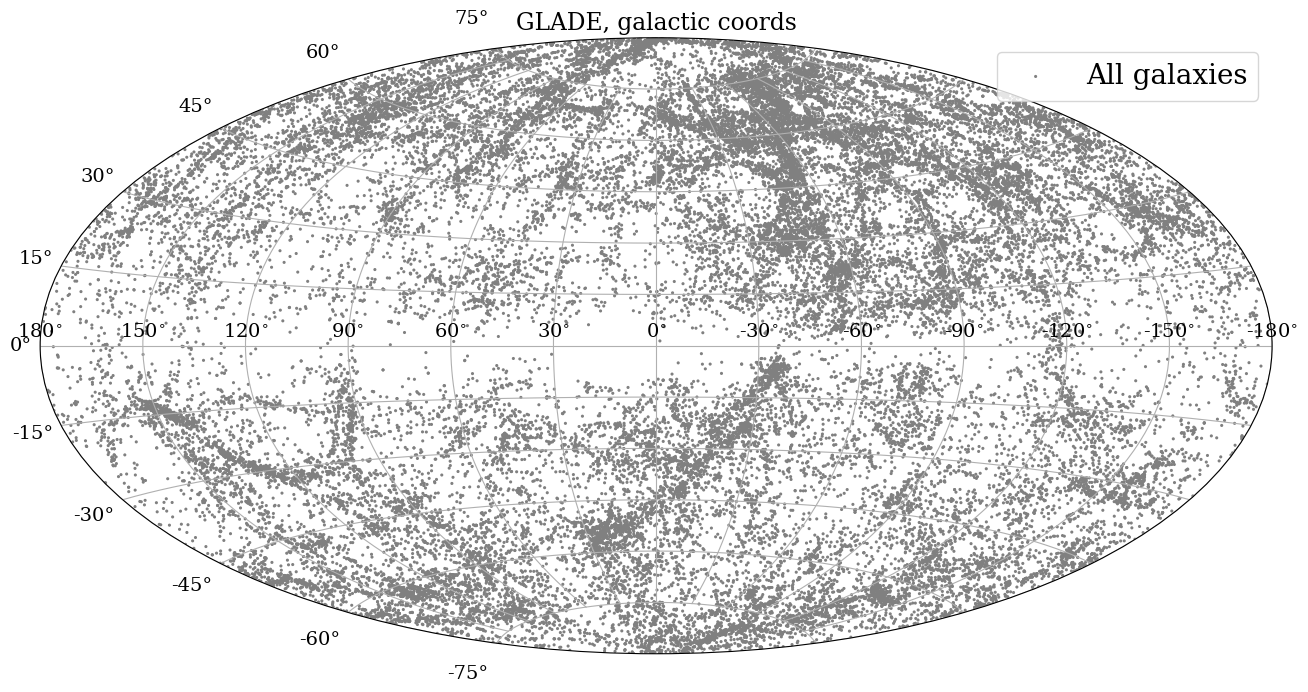

In [19]:
plt.figure(figsize=(16,8))
Aitoff_on_sky_setup()

plt.title("GLADE, galactic coords")
plt.grid(True)
plt.scatter(-1*l, b, c = 'gray', s = 5, edgecolors = 'none', label='All galaxies', alpha=1)
legend = plt.legend(loc='upper right', shadow=False, fontsize=20)
plt.savefig('Galaxy_locations_GLADE2.jpg')

remember your ra_like and dec_like need to be in radians
remember to multiply your ra_like by -1


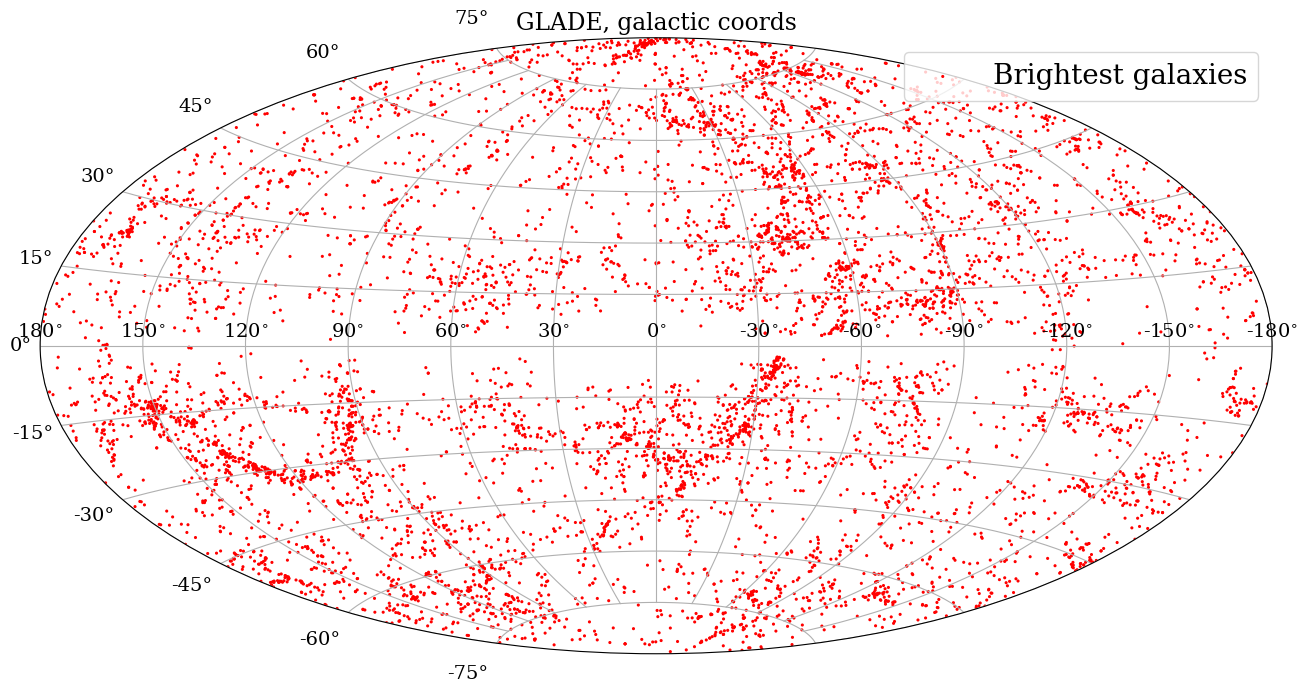

In [21]:
brightest = Babs < -20.5

plt.figure(figsize=(16,8))
Aitoff_on_sky_setup()

plt.title("GLADE, galactic coords")
plt.grid(True)
plt.scatter(-1*l[brightest], b[brightest], c = 'red', s = 5, edgecolors = 'none', label='Brightest galaxies', alpha=1)
legend = plt.legend(loc='upper right', shadow=False, fontsize=20)
plt.savefig('GLADE2_brightest_galaxies_locations.jpg')


remember your ra_like and dec_like need to be in radians
remember to multiply your ra_like by -1


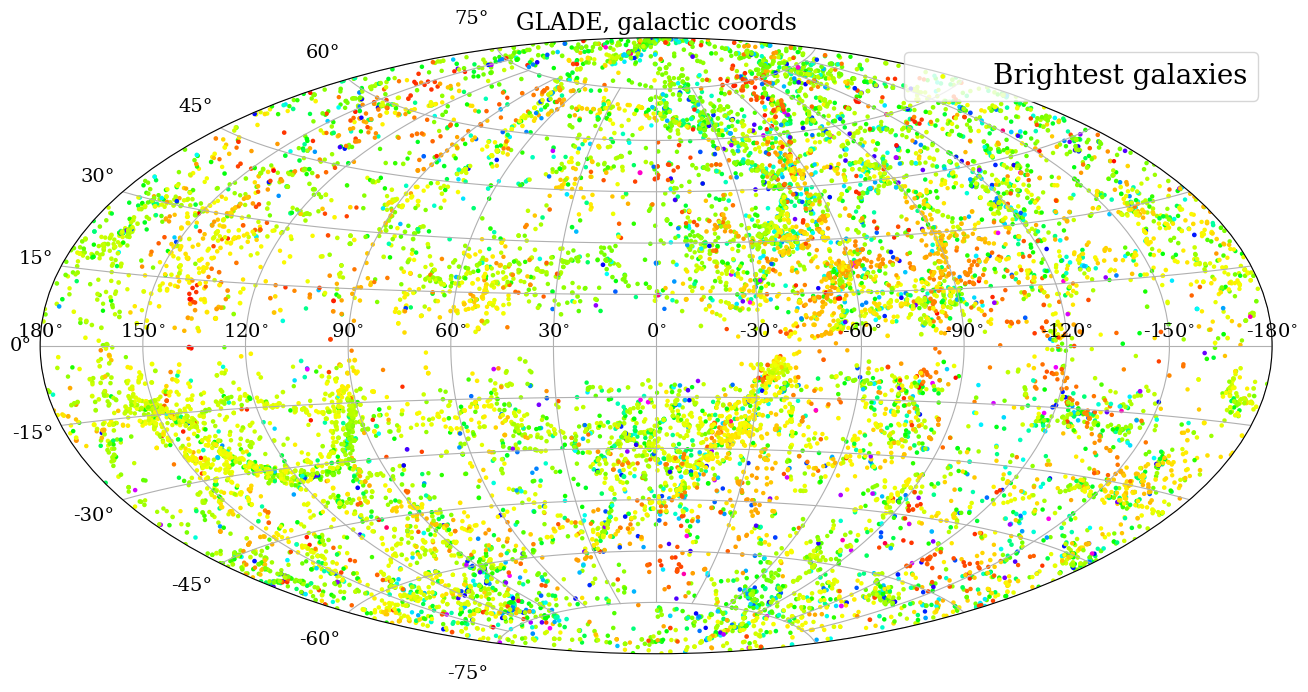

In [23]:
brightest = Babs < -20
size = -1 * Babs - 10
# use colormap hsv from https://matplotlib.org/stable/tutorials/colors/colormaps.html


plt.figure(figsize=(16,8))
Aitoff_on_sky_setup()

plt.title("GLADE, galactic coords")
plt.grid(True)
plt.scatter(-1*l[brightest], b[brightest], c = np.floor(Dist[brightest]), s = size[brightest], edgecolors = 'none', label='Brightest galaxies', alpha=1, cmap = 'hsv')
legend = plt.legend(loc='upper right', shadow=False, fontsize=20)
plt.savefig('GLADE2_locations_zColors.jpg')


<Figure size 640x480 with 0 Axes>

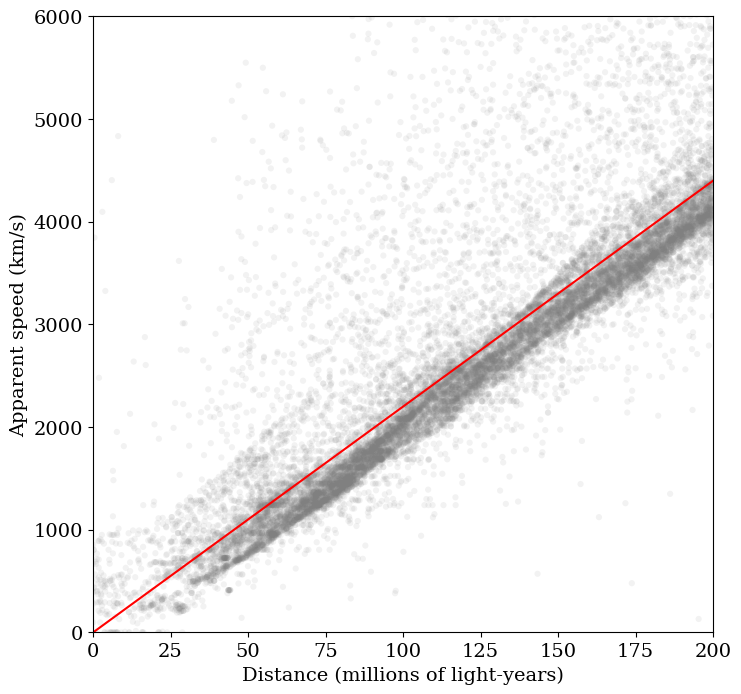

In [25]:
local = Dist * 3.26156 < 200


# plot positions on sky
plt.clf()
plt.figure(figsize=(8,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (km/s)')
plt.xlim(0, 200)
plt.ylim(0, 6000)

plt.scatter(Dist[local] * 3.26156, z[local]*c / 1E3, c = 'gray', s = 20, edgecolors = 'none', alpha=0.1)
plt.plot([0,1200], [0,22*1200], c='red')
plt.savefig('Hubble_plot_100Mly.jpg')

In [5]:
dataFile = 'Freedman2001_Cepheid.csv'
NGC, D_Ceph, v_Ceph = np.loadtxt(dataFile, unpack = True, delimiter=',')

print(len(D_Ceph))
print(D_Ceph, v_Ceph)



22
[ 2.   16.14 17.95 21.88 11.75  3.22 11.22  3.63 13.8  10.   10.52  6.64
 15.21 17.7  14.86 15.78 14.93 16.22 21.98 12.36  3.15 14.72] [ 664. 1794. 1594. 1473.  882.  278.  714.   80.  772.  642.  768.  609.
 1433.  619. 1424. 1444. 1423. 1384. 1403. 1103.  232.  999.]


In [6]:
dataFile = 'Freedman2001_SN1A.csv'
SN1A, D_SN1A, v_SN1A = np.loadtxt(dataFile, unpack = True, delimiter=',')

print(len(D_SN1A))
print(D_SN1A, v_SN1A)



36
[134.7 158.9 198.6 238.9 117.1  56.  183.9 121.5 274.6 102.1  58.  467.
 262.2  88.6 151.4 202.5 235.9 176.8  77.9 309.5 391.5 280.1 303.4 236.1
 215.4 119.7 202.3  71.8  96.7 127.8  66.8 149.9 185.6  82.4 136.  132.7] [ 9065. 12012. 15055. 16687.  9801.  4124. 13707.  7880. 22426.  7765.
  4227. 30253. 18212.  5935. 10696. 13518. 17371. 12871.  5434. 23646.
 26318. 18997. 21190. 15567. 15002.  8604. 14764.  5424.  7241.  8691.
  4847. 10715. 14634.  6673.  9024. 10446.]


<Figure size 640x480 with 0 Axes>

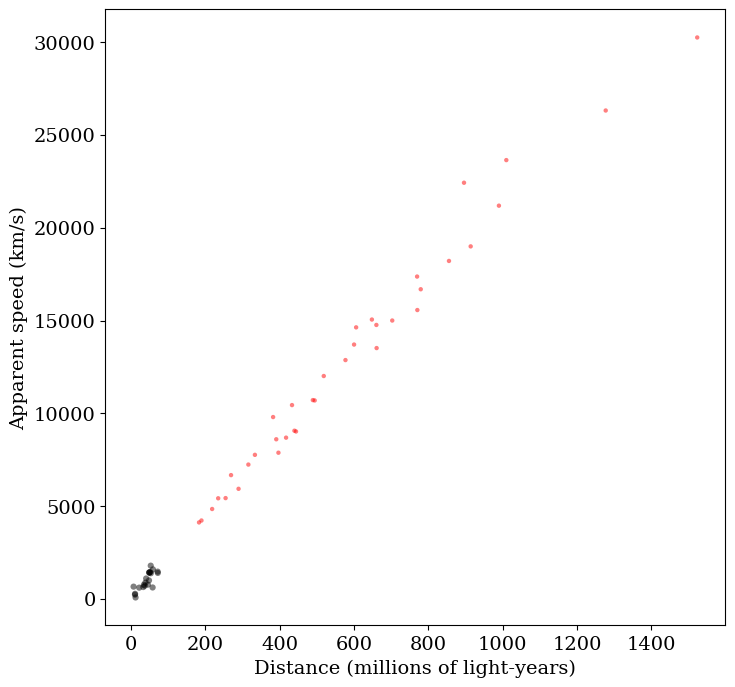

In [31]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(8,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (km/s)')
#plt.xlim(0, 200)
#plt.ylim(0, 6000)

plt.scatter(D_Ceph * 3.26156, v_Ceph, c = 'black', s = 20, edgecolors = 'none', alpha=0.5)
plt.scatter(D_SN1A * 3.26156, v_SN1A, c = 'red', s = 10, edgecolors = 'none', alpha=0.5)
#plt.plot([0,1200], [0,22*1200], c='red')
plt.savefig('Hubble_plot_Freedman.jpg')

<Figure size 432x288 with 0 Axes>

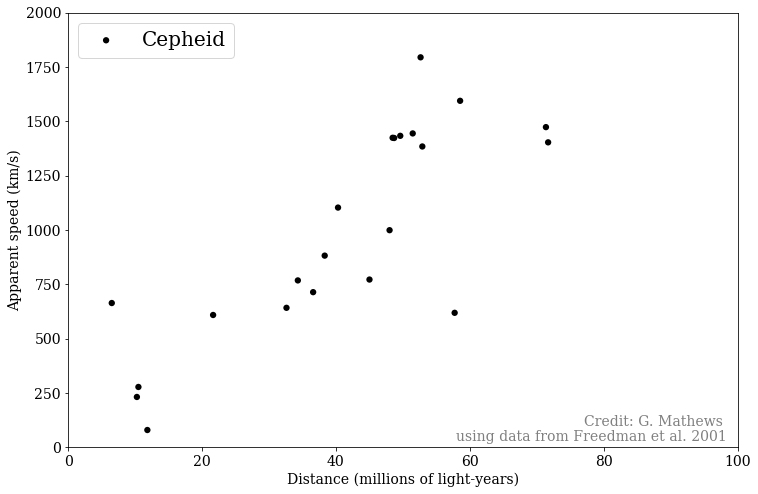

In [90]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(12,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (km/s)')
plt.xlim(0, 100)
plt.ylim(0, 2000)

plt.scatter(D_Ceph * 3.26156, v_Ceph, c = 'black', s = 40, edgecolors = 'none', alpha=1, label='Cepheid')
#plt.scatter(D_SN1A * 3.26156, v_SN1A, c = 'red', s = 10, edgecolors = 'none', alpha=0.5)
#plt.plot([0,1200], [0,22*1200], c='red')
plt.annotate('Credit: G. Mathews', xy=(77, 100), color='gray')
plt.annotate('using data from Freedman et al. 2001', xy=(58, 30), color='gray')
legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_Cepheids.jpg')

<Figure size 432x288 with 0 Axes>

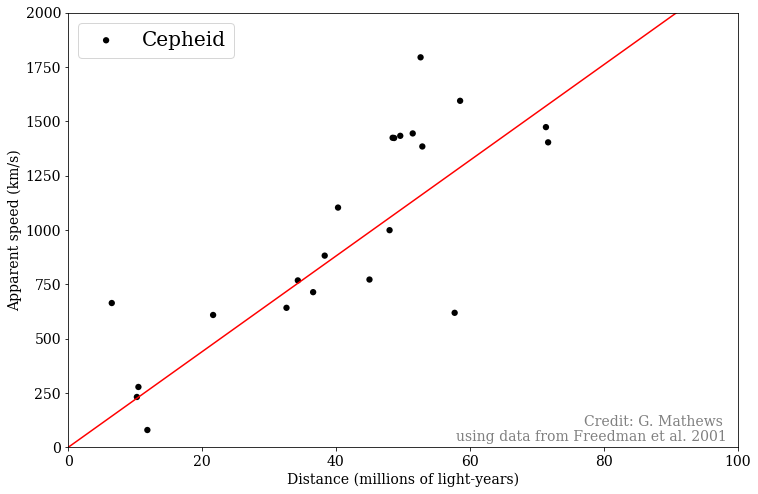

In [99]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(12,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (km/s)')
plt.xlim(0, 100)
plt.ylim(0, 2000)

plt.scatter(D_Ceph * 3.26156, v_Ceph, c = 'black', s = 40, edgecolors = 'none', alpha=1, label='Cepheid')
#plt.scatter(D_SN1A * 3.26156, v_SN1A, c = 'red', s = 10, edgecolors = 'none', alpha=0.5)
plt.plot([0,1200], [0,22*1200], c='red')
plt.annotate('Credit: G. Mathews', xy=(77, 100), color='gray')
plt.annotate('using data from Freedman et al. 2001', xy=(58, 30), color='gray')
legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_Cepheids_with_trend.jpg')

<Figure size 432x288 with 0 Axes>

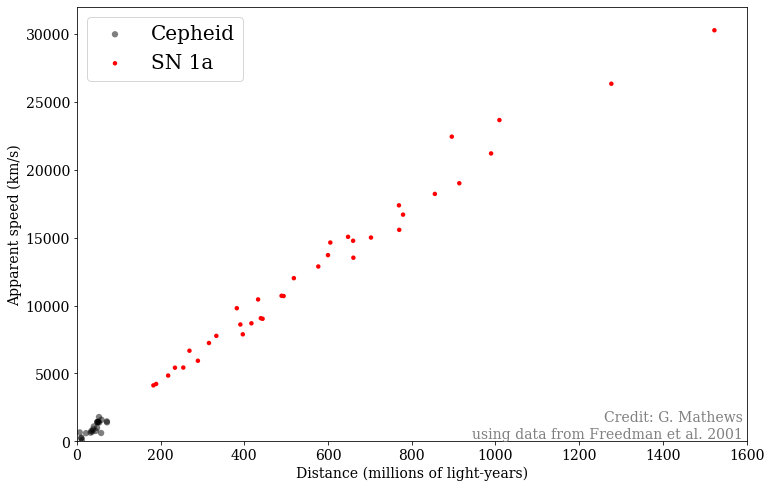

In [103]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(12,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (km/s)')
plt.xlim(0, 1600)
plt.ylim(0, 32000)

plt.scatter(D_Ceph * 3.26156, v_Ceph, c = 'black', s = 40, edgecolors = 'none', alpha=0.5, label='Cepheid')
plt.scatter(D_SN1A * 3.26156, v_SN1A, c = 'red', s = 20, edgecolors = 'none', alpha=1, label='SN 1a')
#plt.plot([0,1200], [0,22*1200], c='red')
plt.annotate('Credit: G. Mathews', xy=(1260, 1500), color='gray')
plt.annotate('using data from Freedman et al. 2001', xy=(945, 200), color='gray')
legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_SN1A.jpg')

<Figure size 432x288 with 0 Axes>

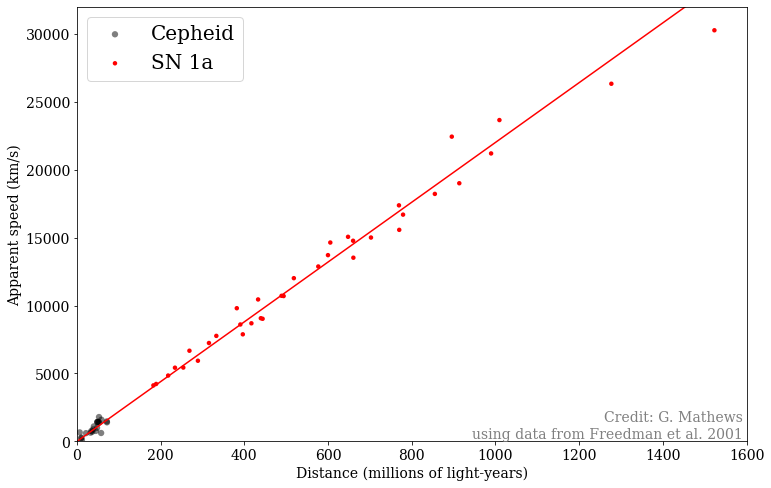

In [102]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(12,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (km/s)')
plt.xlim(0, 1600)
plt.ylim(0, 32000)

plt.scatter(D_Ceph * 3.26156, v_Ceph, c = 'black', s = 40, edgecolors = 'none', alpha=0.5, label='Cepheid')
plt.scatter(D_SN1A * 3.26156, v_SN1A, c = 'red', s = 20, edgecolors = 'none', alpha=1, label='SN 1a')
plt.plot([0,2000], [0,22*2000], c='red')
plt.annotate('Credit: G. Mathews', xy=(1260, 1500), color='gray')
plt.annotate('using data from Freedman et al. 2001', xy=(945, 200), color='gray')
legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_SN1A_with_trend.jpg')

<Figure size 640x480 with 0 Axes>

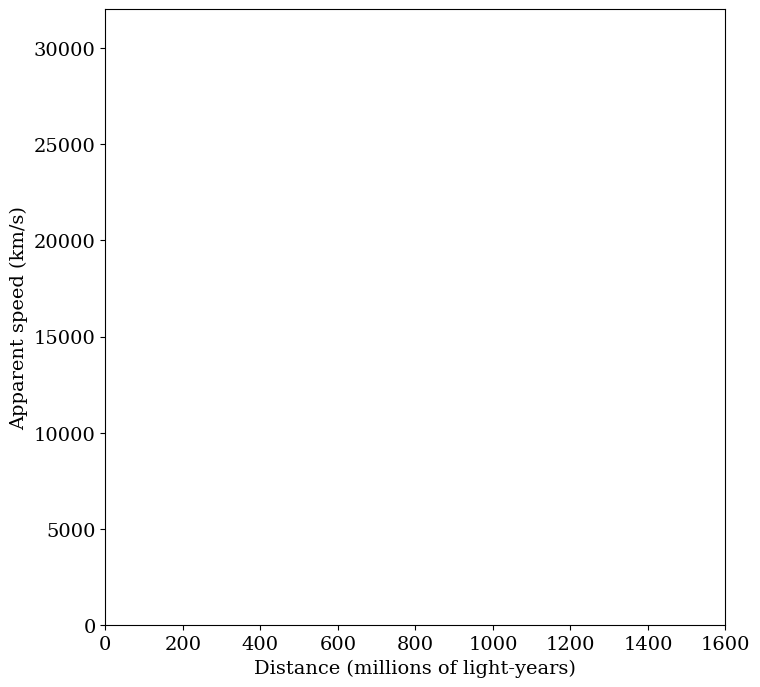

In [35]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(8,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (km/s)')
plt.xlim(0, 1600)
plt.ylim(0, 32000)

plt.scatter(0,0, s=0.0001)
#plt.scatter(D_Ceph * 3.26156, v_Ceph, c = 'black', s = 40, edgecolors = 'none', alpha=0.5, label='Cepheid')
#plt.scatter(D_SN1A * 3.26156, v_SN1A, c = 'red', s = 20, edgecolors = 'none', alpha=1, label='SN 1a')
#plt.plot([0,2000], [0,22*2000], c='red')
#plt.annotate('Credit: G. Mathews', xy=(1260, 1500), color='gray')
#plt.annotate('using data from Freedman et al. 2001', xy=(945, 200), color='gray')
#legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_blank.jpg')

<Figure size 432x288 with 0 Axes>

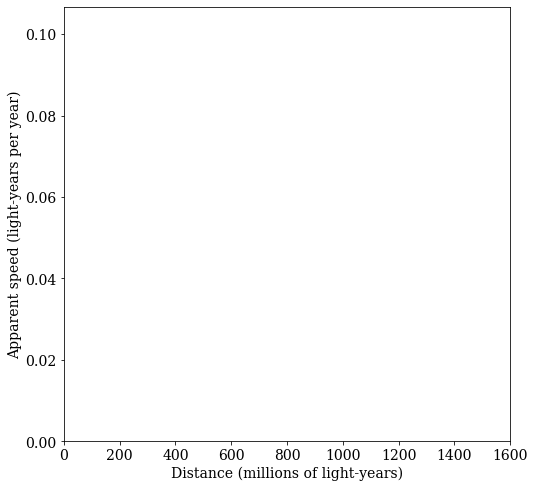

In [5]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(8,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (light-years per year)')
plt.xlim(0, 1600)
plt.ylim(0, 32000 / 2.997E5)

plt.scatter(0,0, s=0.0001)
#plt.scatter(D_Ceph * 3.26156, v_Ceph, c = 'black', s = 40, edgecolors = 'none', alpha=0.5, label='Cepheid')
#plt.scatter(D_SN1A * 3.26156, v_SN1A, c = 'red', s = 20, edgecolors = 'none', alpha=1, label='SN 1a')
#plt.plot([0,2000], [0,22*2000], c='red')
#plt.annotate('Credit: G. Mathews', xy=(1260, 1500), color='gray')
#plt.annotate('using data from Freedman et al. 2001', xy=(945, 200), color='gray')
#legend = plt.legend(loc='upper left', shadow=False, fontsize=20)

plt.savefig('Hubble_plot_blank_speed_as_c.jpg')

<Figure size 640x480 with 0 Axes>

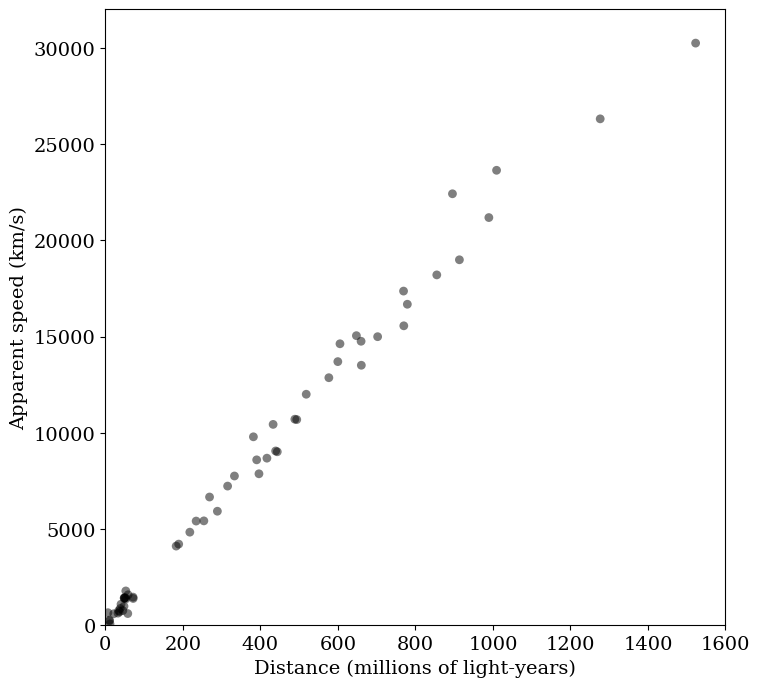

In [37]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(8,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (km/s)')
plt.xlim(0, 1600)
plt.ylim(0, 32000)

plt.scatter(0,0, s=0.0001)
plt.scatter(D_Ceph * 3.26156, v_Ceph, c = 'black', s = 40, edgecolors = 'none', alpha=0.5, label='Cepheid')
plt.scatter(D_SN1A * 3.26156, v_SN1A, c = 'black', s = 40, edgecolors = 'none', alpha=0.5, label='SN 1a')
#plt.plot([0,2000], [0,22*2000], c='red')
#plt.annotate('Credit: G. Mathews', xy=(1260, 1500), color='gray')
#plt.annotate('using data from Freedman et al. 2001', xy=(945, 200), color='gray')
#legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_all_data.jpg')

In [54]:
dataFile = 'CosmicFlows.tsv'
#dataFile = 'test.tsv'
PGC, HRV, u_mag, RA, DE, DMbest = np.loadtxt(dataFile, unpack = True, delimiter='|')

print(len(DMbest))
print(DMbest, HRV)
print(np.min(DMbest), np.max(DMbest))

distance = 10**((DMbest + 5 ) / 5)*1E-6*3.26
print(np.min(distance), np.max(distance))

ra_a = coord.Angle(RA * u.degree)
dec_a = coord.Angle(DE * u.degree)
ra_wrap = ra_a.wrap_at(180 * u.degree)
ra = ra_wrap.radian
dec = dec_a.radian

sc = SkyCoord(ra=RA, dec=DE, unit='deg', frame='fk5', equinox='J2000.0')
l = sc.transform_to('galactic').l
b = sc.transform_to('galactic').b
l_wrap = l.wrap_at(180 * u.degree)
l = l_wrap.radian
b = b.radian
print(l, b)

6775
[33.29 34.7  34.   ... 32.03 34.15 33.34] [4458. 5667. 4779. ... 3095. 7204. 4888.]
27.65 38.6
11.046319490137986 1710.8723204142611
[1.88203164 1.59872609 1.93643492 ... 1.74987838 2.17123227 2.62084045] [-0.66799149 -1.132118   -0.49019483 ... -0.96903022 -0.72254471
 -0.40260651]


remember your ra_like and dec_like need to be in radians
remember to multiply your ra_like by -1


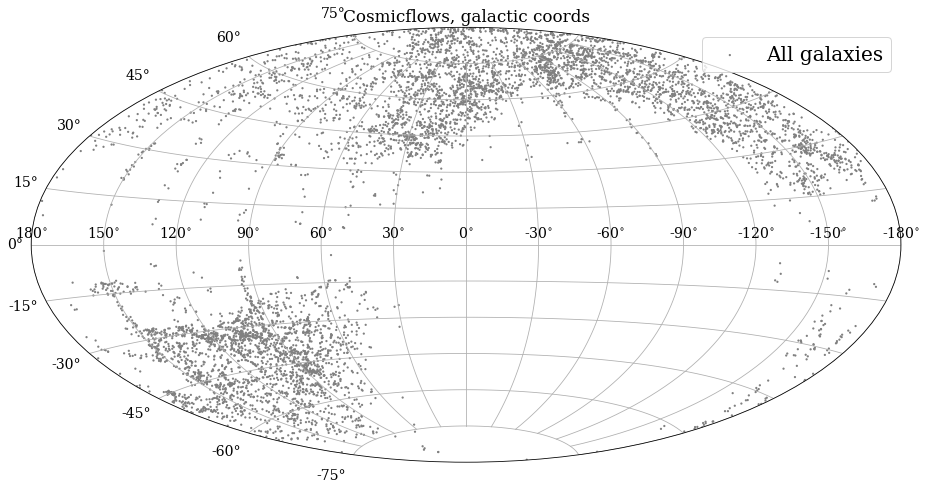

In [48]:
plt.figure(figsize=(16,8))
Aitoff_on_sky_setup()

plt.title("Cosmicflows, galactic coords")
plt.grid(True)
plt.scatter(-1*l, b, c = 'gray', s = 5, edgecolors = 'none', label='All galaxies', alpha=1)
legend = plt.legend(loc='upper right', shadow=False, fontsize=20)
plt.savefig('Galaxy_locations_Cosmicflows.jpg')

<Figure size 432x288 with 0 Axes>

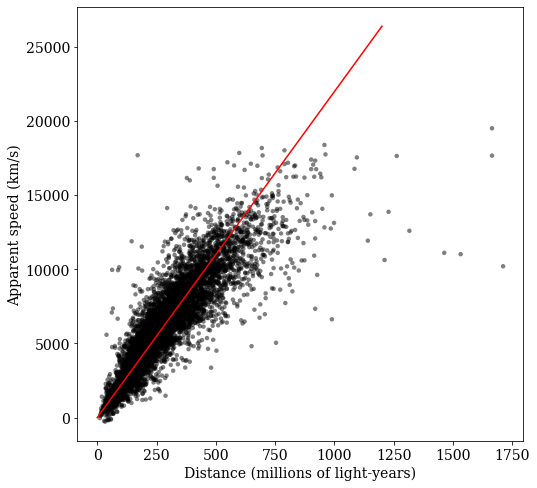

In [56]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(8,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (km/s)')
#plt.xlim(0, 200)
#plt.ylim(0, 6000)

plt.scatter(distance, HRV, c = 'black', s = 20, edgecolors = 'none', alpha=0.5)
#plt.scatter(D_SN1A * 3.26156, v_SN1A, c = 'red', s = 10, edgecolors = 'none', alpha=0.5)
plt.plot([0,1200], [0,22*1200], c='red')
plt.savefig('Hubble_plot_Cosmicflows.jpg')

In [ ]:

###################
##
## generate a fake universe with a constant Hubble law

# Hubble constant, in km/s / Million light-years
H0 = 22.0

# distance, in millions of light-years
distance = np.arange(0,10000,1)
speed = H0 * distance

n_gal = 30
max_distance = 95
#speed_err = 20000
speed_err = 0.05
#galaxy_distances = np.random.uniform(500,20000,n_gal)
galaxy_distances = np.random.uniform(10,2000,n_gal)
#galaxy_speeds = H0 * galaxy_distances + np.random.normal(0,speed_err,n_gal)
galaxy_speeds = H0 * galaxy_distances * (1.0 + np.random.normal(0,speed_err,n_gal))

fig = plt.figure()
#plt.plot(distance,speed, linewidth=3)
plt.plot(galaxy_distances,galaxy_speeds, 'ko',markersize=15)

#plt.ylim(0,400000)
#plt.xlim(0,20000)
plt.ylim(0,40000)
plt.xlim(0,2000)
plt.xlabel(r'Distance [millions of light-years]', fontsize=20)
plt.ylabel(r'Apparent speed [km/s]', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)

plt.plot([0,100000], [3E5, 3E5], linewidth=5, color='red')
plt.annotate('Speed of light',xy=(2500, 3.3E5), xytext=(0,0), fontsize=20, textcoords='offset points', ha='center', va='top',color='red')

ax = fig.gca()
ax.grid(True)
grid(linestyle='dashed', linewidth=2,color='gray')



<Figure size 640x480 with 0 Axes>

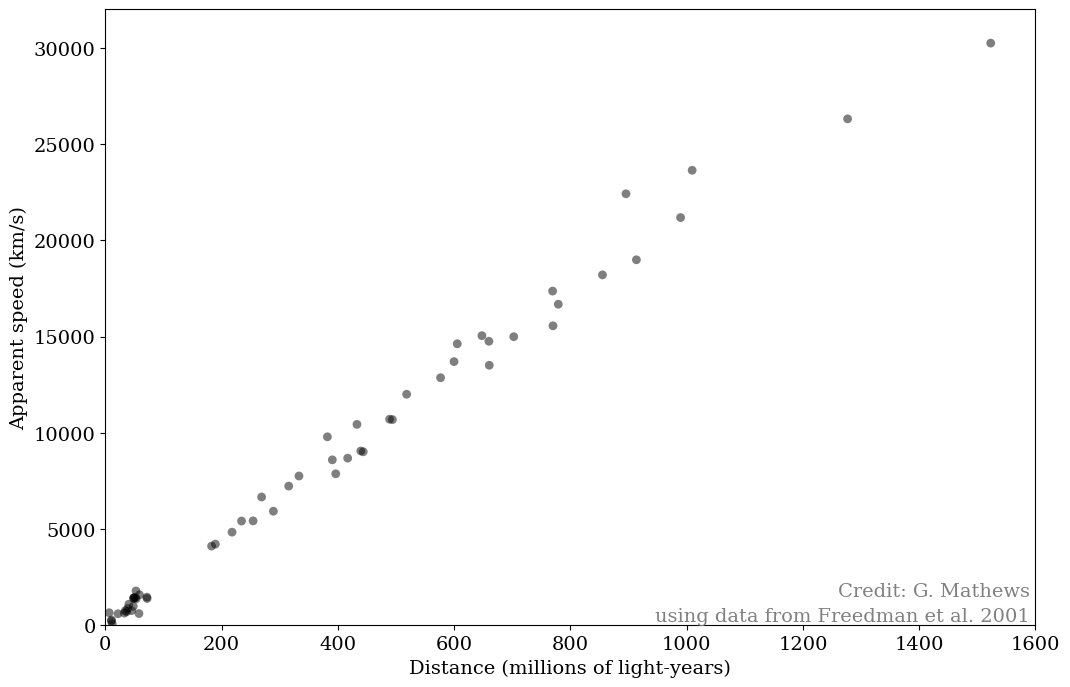

In [7]:
# plot positions on sky
plt.clf()
plt.figure(figsize=(12,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (km/s)')
plt.xlim(0, 1600)
plt.ylim(0, 32000)

plt.scatter(0,0, s=0.0001)
plt.scatter(D_Ceph * 3.26156, v_Ceph, c = 'black', s = 40, edgecolors = 'none', alpha=0.5, label='Cepheid')
plt.scatter(D_SN1A * 3.26156, v_SN1A, c = 'black', s = 40, edgecolors = 'none', alpha=0.5, label='SN 1a')
#plt.plot([0,2000], [0,22*2000], c='red')
plt.annotate('Credit: G. Mathews', xy=(1260, 1500), color='gray')
plt.annotate('using data from Freedman et al. 2001', xy=(945, 200), color='gray')
#legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_all_data_km_s.jpg')

<Figure size 640x480 with 0 Axes>

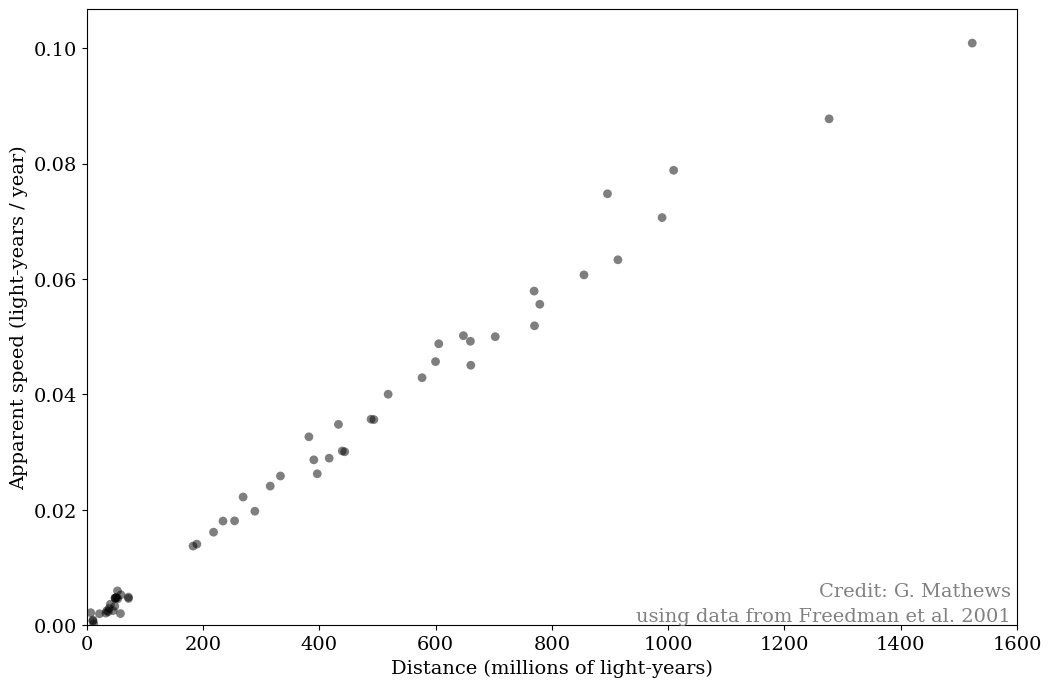

In [15]:
kms_to_lyy = 3.154E7 / 9.461E12


# plot positions on sky
plt.clf()
plt.figure(figsize=(12,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (light-years / year)')
plt.xlim(0, 1600)
plt.ylim(0, 32000 * kms_to_lyy)


plt.scatter(0,0, s=0.0001)
plt.scatter(D_Ceph * 3.26156, v_Ceph * kms_to_lyy, c = 'black', s = 40, edgecolors = 'none', alpha=0.5, label='Cepheid')
plt.scatter(D_SN1A * 3.26156, v_SN1A * kms_to_lyy, c = 'black', s = 40, edgecolors = 'none', alpha=0.5, label='SN 1a')
#plt.plot([0,2000], [0,22*2000], c='red')
plt.annotate('Credit: G. Mathews', xy=(1260, 1500 * kms_to_lyy), color='gray')
plt.annotate('using data from Freedman et al. 2001', xy=(945, 200 * kms_to_lyy), color='gray')
#legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_all_data_ly_y.jpg')

[1326.09853664 1391.08788191  120.55924254  622.232172   1456.6247396
 1118.00886469 1015.38556249  661.66759967  131.50380246  101.92690646
 1162.80879     412.30974919 1270.9501493  1147.28084759 1268.94688742
  930.22701323  659.34534803  494.57868702  909.37603181 1189.90734089
  180.8525217    43.35702013  465.41980616 1048.09280465  603.43496935
 1053.0939435  1274.15406574  753.6849361   625.64085624  155.16857726]
[13050.35650716 14311.53967062  1250.52759435  5183.33457897
 12618.00108006 11442.38499973 10145.89963239  5968.69211648
  1283.22853104  1039.77518378 10561.47948155  3891.48898176
 13719.5626945  13023.94731284 13109.26991782  9338.8805957
  6479.12115954  5077.1801055   8026.18508379 11708.27116916
  2007.16813195   382.47263935  5197.39163975 11958.78512824
  5947.84676348 11349.06259617 12969.38106923  7013.70581701
  7537.06443389  1718.38349249]


<Figure size 640x480 with 0 Axes>

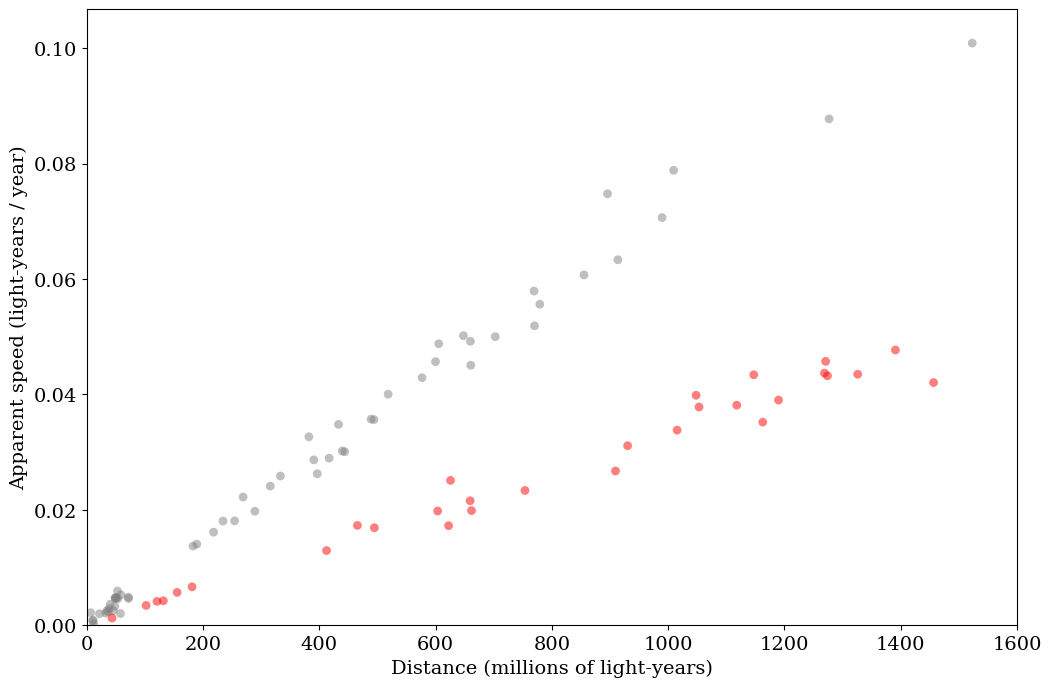

In [26]:
kms_to_lyy = 3.154E7 / 9.461E12

n = 30
rand_x = 1500 * np.random.rand(n)
rand_y = (np.random.normal(0,0.1,n) + 1) * rand_x * 10
print(rand_x)
print(rand_y)

# plot positions on sky
plt.clf()
plt.figure(figsize=(12,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (light-years / year)')
plt.xlim(0, 1600)
plt.ylim(0, 32000 * kms_to_lyy)


plt.scatter(0,0, s=0.0001)
plt.scatter(D_Ceph * 3.26156, v_Ceph * kms_to_lyy, c = 'gray', s = 40, edgecolors = 'none', alpha=0.5, label='Cepheid')
plt.scatter(D_SN1A * 3.26156, v_SN1A * kms_to_lyy, c = 'gray', s = 40, edgecolors = 'none', alpha=0.5, label='SN 1a')
plt.scatter(rand_x, rand_y * kms_to_lyy, c = 'red', s = 40, edgecolors = 'none', alpha=0.5, label='model')
#plt.plot([0,2000], [0,22*2000], c='red')
#plt.annotate('Credit: G. Mathews', xy=(1260, 1500 * kms_to_lyy), color='gray')
#plt.annotate('using data from Freedman et al. 2001', xy=(945, 200 * kms_to_lyy), color='gray')
#legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_all_data_vs_old.jpg')

<Figure size 640x480 with 0 Axes>

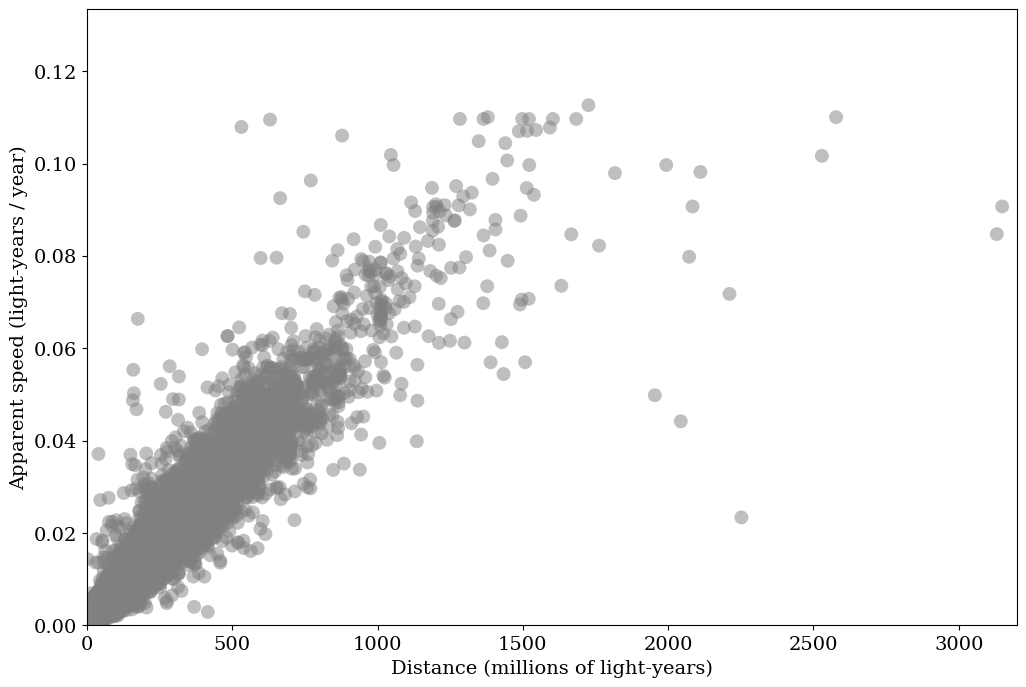

In [37]:
dataFile = 'NED-D.tsv'
#dataFile = 'test.tsv'
RAJ2000, DEJ2000, GLON, GLAT, z, RVel, BED3, e_BED3, RAicrs, DEicrs  = np.loadtxt(dataFile, unpack = True, delimiter='|', skiprows=98)

# plot positions on sky
plt.clf()
plt.figure(figsize=(12,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (light-years / year)')
plt.xlim(0, 3200)
plt.ylim(0, 40000 * kms_to_lyy)


plt.scatter(0,0, s=0.0001)
plt.scatter(BED3 * 3.26156, z * 2.99E5 * kms_to_lyy, c = 'gray', s = 100, edgecolors = 'none', alpha=0.5, label='NED')
#plt.plot([0,2000], [0,22*2000], c='red')
#plt.annotate('Credit: G. Mathews', xy=(1260, 1500 * kms_to_lyy), color='gray')
#plt.annotate('using data from Freedman et al. 2001', xy=(945, 200 * kms_to_lyy), color='gray')
#legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_NED.jpg')

<Figure size 640x480 with 0 Axes>

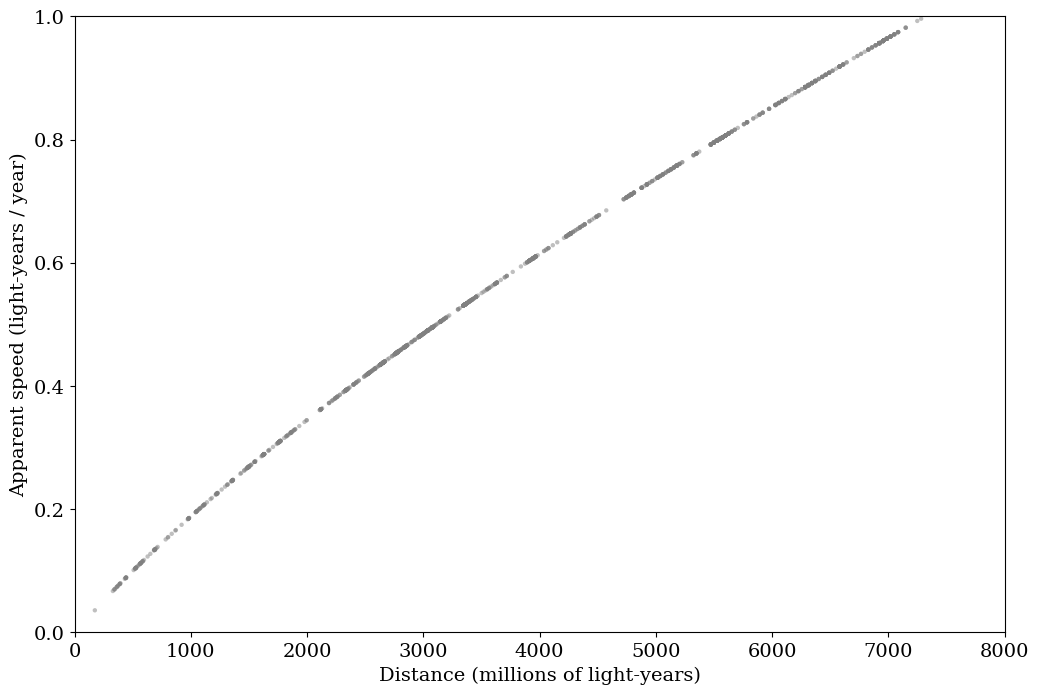

In [65]:
dataFile = 'GLADE_HDF_times10.tsv'
#dataFile = 'test.tsv'
d, z  = np.loadtxt(dataFile, unpack = True, delimiter='|', skiprows=37)

# plot positions on sky
plt.clf()
plt.figure(figsize=(12,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (light-years / year)')
plt.xlim(0, 8000)
plt.ylim(0, 1)


plt.scatter(0,0, s=0.0001)
plt.scatter(d * 3.26156 / 3, z, c = 'gray', s = 10, edgecolors = 'none', alpha=0.5, label='GLADE')
#plt.plot([0,2000], [0,22*2000], c='red')
#plt.annotate('Credit: G. Mathews', xy=(1260, 1500 * kms_to_lyy), color='gray')
#plt.annotate('using data from Freedman et al. 2001', xy=(945, 200 * kms_to_lyy), color='gray')
#legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_GLAD_HubbleDeepField.jpg')

<Figure size 640x480 with 0 Axes>

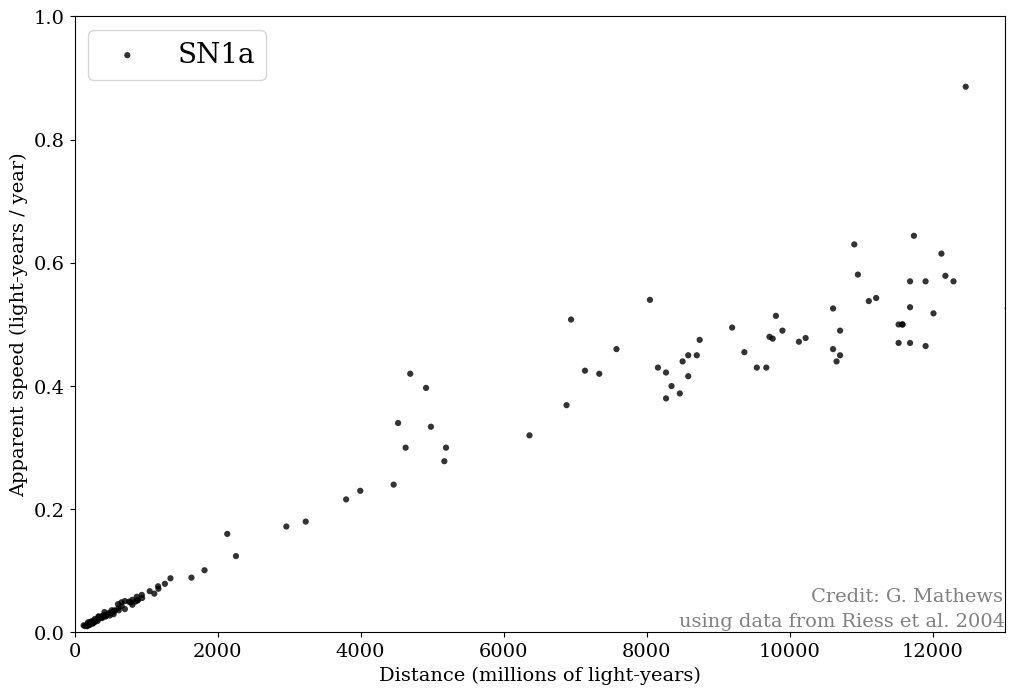

In [77]:
dataFile = 'Riess2004_Hubble_SN1a.tsv'
#dataFile = 'test.tsv'
z, mu  = np.loadtxt(dataFile, unpack = True, delimiter='|', skiprows=253)
d = 10**((mu + 5)/5)

# plot positions on sky
plt.clf()
plt.figure(figsize=(12,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (light-years / year)')
plt.xlim(0, 13000)
plt.ylim(0, 1)


plt.scatter(0,0, s=0.0001)
plt.scatter(d * 3.26156 / 1E6, z, c = 'black', s = 20, edgecolors = 'none', alpha=0.8, label='SN1a')
#plt.plot([0,2000], [0,22*2000], c='red')
plt.annotate('Credit: G. Mathews', xy=(10300, 0.05), color='gray')
plt.annotate('using data from Riess et al. 2004', xy=(8450, 0.01), color='gray')
legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_Riesss_SN1a_2004.jpg')

i:  1
j:  0  H0[j]:  200  dlims:  2500 0
offset:  0.5110569262725971
i:  2
j:  0  H0[j]:  200  dlims:  2500 0
offset:  0.5110569262725971
j:  1  H0[j]:  10  dlims:  8000 2500
offset:  0.5672731881625828


<Figure size 640x480 with 0 Axes>

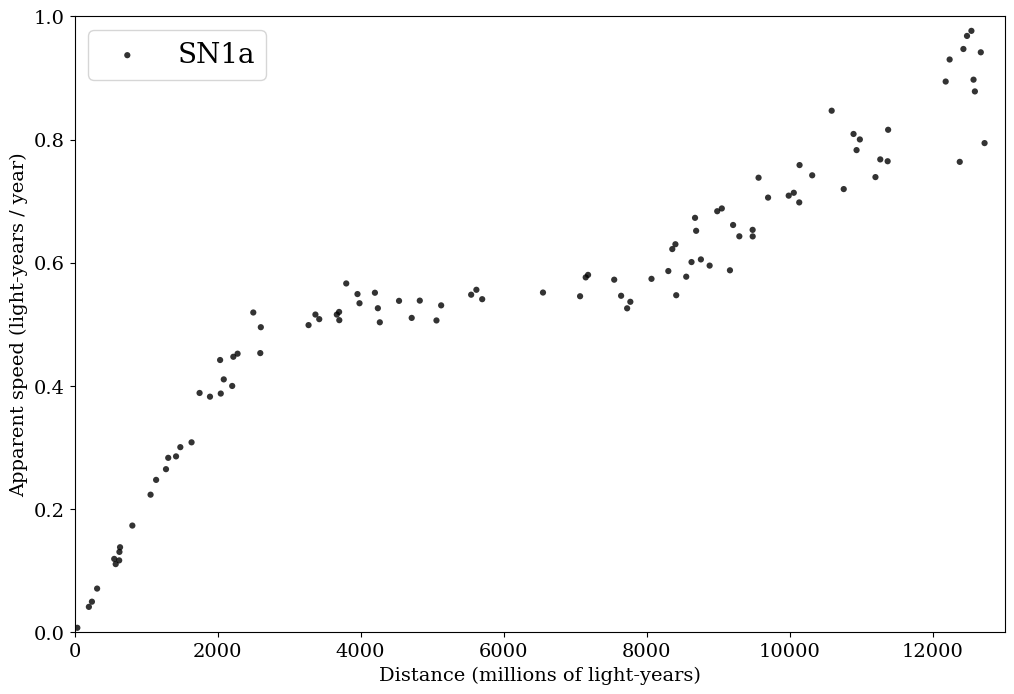

In [93]:
# model dataset
kms_to_lyy = 3.154E7 / 9.461E12
n = 100

H0s = [200, 10, 70]
kms_Mpc_to_lyy_Mly = kms_to_lyy / 3.26156
dlims = [0,2500,8000, 13000]

d = (dlims[-1] - dlims[0]) * np.random.rand(n)
z = np.zeros_like(d)

for i in range(len(H0s)):
    a = ((d > dlims[i]) & (d<= dlims[i+1]))
    offset = 0
    if i > 0:
        print('i: ',i)
        for j in range(0,i):
            print('j: ',j, ' H0[j]: ', H0s[j], ' dlims: ', dlims[j+1], dlims[j])
            offset += H0s[j] * kms_Mpc_to_lyy_Mly * (dlims[j+1] - dlims[j])
            print('offset: ', offset)
    z[a] = ((d[a] - dlims[i]) * H0s[i] * kms_Mpc_to_lyy_Mly + offset) * np.random.normal(1,0.05,sum(a))


# plot positions on sky
plt.clf()
plt.figure(figsize=(12,8))
plt.xlabel('Distance (millions of light-years)')
plt.ylabel('Apparent speed (light-years / year)')
plt.xlim(0, 13000)
plt.ylim(0, 1)


plt.scatter(0,0, s=0.0001)
plt.scatter(d, z, c = 'black', s = 20, edgecolors = 'none', alpha=0.8, label='SN1a')
#plt.plot([0,2000], [0,22*2000], c='red')
#plt.annotate('Credit: G. Mathews', xy=(10300, 0.05), color='gray')
#plt.annotate('using data from Riess et al. 2004', xy=(8450, 0.01), color='gray')
legend = plt.legend(loc='upper left', shadow=False, fontsize=20)
plt.savefig('Hubble_plot_model_a.jpg')